# HOG — Indian Digit Classifier

Traditional CV pipeline: HOG features → SVM / Random Forest 


## 0️⃣ Install Dependencies

> Run this cell first. `%pip` installs into the currently-running kernel.

In [ ]:
%pip install scikit-image scikit-learn pillow --quiet

## 1️⃣ Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


## 2️⃣ Load Dataset

In [2]:
training_images_dir = '../Data/training_images'
training_labels_dir = '../Data/training_labels'
test_labels_dir     = '../Data/test_labels'
test_images_dir     = '../Data/test_images'

train_df = pd.read_csv(os.path.join(training_labels_dir, 'train.csv'))
test_df  = pd.read_csv(os.path.join(test_labels_dir,    'test.csv'))
original_test_ids = test_df['Id'].copy()

train_df['Id'] = train_df['Id'].astype(str) + '.png'
test_df['Id']  = test_df['Id'].astype(str)  + '.png'

print(f'Training samples: {len(train_df)}')
print(f'Test samples    : {len(test_df)}')

Training samples: 17000
Test samples    : 3000


## 3️⃣ HOG Feature Extraction

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `pixels_per_cell` | (8,8) | cell size |
| `cells_per_block` | (2,2) | normalisation block |
| `orientations` | 9 | gradient bins |

Yields a **144-D** feature vector per 32×32 image.

In [3]:
IMG_SIZE      = (32, 32)
ORIENTATIONS  = 9
PIX_PER_CELL  = (8, 8)
CELLS_PER_BLK = (2, 2)

def load_and_extract_hog(image_dir, filenames):
    features = []
    for fname in filenames:
        img = Image.open(os.path.join(image_dir, fname)).convert('L')
        img = img.resize(IMG_SIZE, Image.LANCZOS)
        arr = np.array(img) / 255.0
        fd  = hog(arr, orientations=ORIENTATIONS, pixels_per_cell=PIX_PER_CELL,
                  cells_per_block=CELLS_PER_BLK, block_norm='L2-Hys', visualize=False)
        features.append(fd)
    return np.array(features)

print('Extracting HOG features from TRAINING set ...')
X_train = load_and_extract_hog(training_images_dir, train_df['Id'].values)
y_train = train_df['Category'].values
print(f'Training feature matrix: {X_train.shape}')

print('Extracting HOG features from TEST set ...')
X_test = load_and_extract_hog(test_images_dir, test_df['Id'].values)
print(f'Test feature matrix    : {X_test.shape}')

Extracting HOG features from TRAINING set ...
Training feature matrix: (17000, 324)
Extracting HOG features from TEST set ...
Test feature matrix    : (3000, 324)


## 4️⃣ Visualise HOG Descriptors

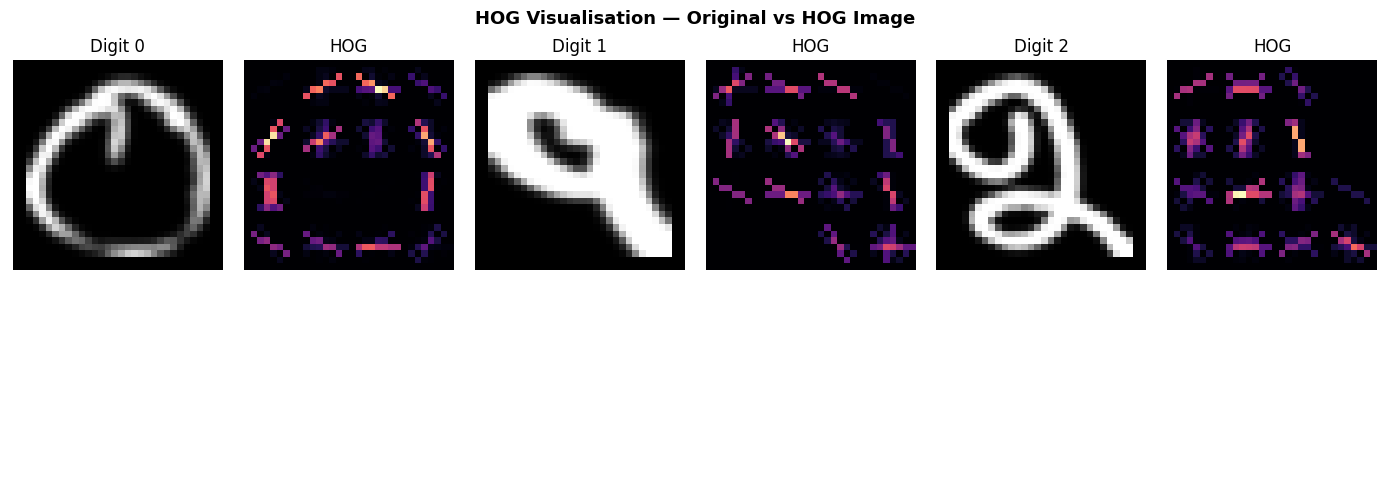

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('HOG Visualisation — Original vs HOG Image', fontsize=13, fontweight='bold')
sample_indices = [np.where(y_train == cls)[0][0] for cls in range(10)]
for col, idx in enumerate(sample_indices[:3]):
    fname = train_df['Id'].values[idx]
    img   = Image.open(os.path.join(training_images_dir, fname)).convert('L')
    img   = img.resize(IMG_SIZE, Image.LANCZOS)
    arr   = np.array(img) / 255.0
    fd, hog_img = hog(arr, orientations=ORIENTATIONS, pixels_per_cell=PIX_PER_CELL,
                      cells_per_block=CELLS_PER_BLK, block_norm='L2-Hys', visualize=True)
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    axes[0][col*2].imshow(arr, cmap='gray'); axes[0][col*2].set_title(f'Digit {y_train[idx]}'); axes[0][col*2].axis('off')
    axes[0][col*2+1].imshow(hog_img, cmap='magma'); axes[0][col*2+1].set_title('HOG'); axes[0][col*2+1].axis('off')
for c in range(6): axes[1][c].axis('off')
plt.tight_layout(); plt.show()

## 5️⃣ Train Classifiers

In [5]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])
print('Training SVM ...')
svm_pipeline.fit(X_train, y_train)
print('SVM trained!')

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))
])
print('Training Random Forest ...')
rf_pipeline.fit(X_train, y_train)
print('Random Forest trained!')

Training SVM ...
SVM trained!
Training Random Forest ...
Random Forest trained!


## 6️⃣ Evaluate on Training Data

In [6]:
from sklearn.model_selection import train_test_split
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
# Retrain on the split
svm_pipeline.fit(X_train_split, y_train_split)
rf_pipeline.fit(X_train_split, y_train_split)
# Evaluate on held-out validation data
svm_val_preds = svm_pipeline.predict(X_val)
rf_val_preds  = rf_pipeline.predict(X_val)
print('=== SVM (Validation Set) ===')
print(classification_report(y_val, svm_val_preds, digits=4))
print('=== Random Forest (Validation Set) ===')
print(classification_report(y_val, rf_val_preds, digits=4))

=== SVM (Validation Set) ===
              precision    recall  f1-score   support

           0     0.9971    0.9971    0.9971       340
           1     0.9971    1.0000    0.9985       340
           2     0.9855    0.9971    0.9912       340
           3     0.9911    0.9824    0.9867       340
           4     0.9971    0.9971    0.9971       340
           5     0.9883    0.9971    0.9927       340
           6     0.9911    0.9824    0.9867       340
           7     1.0000    0.9971    0.9985       340
           8     0.9971    1.0000    0.9985       340
           9     1.0000    0.9941    0.9971       340

    accuracy                         0.9944      3400
   macro avg     0.9944    0.9944    0.9944      3400
weighted avg     0.9944    0.9944    0.9944      3400

=== Random Forest (Validation Set) ===
              precision    recall  f1-score   support

           0     1.0000    0.9971    0.9985       340
           1     0.9854    0.9941    0.9898       340
          

## 7️⃣ Cross-Validation

5-fold CV — SVM ...
SVM  CV: 0.9961 ± 0.0010  [0.9962 0.9947 0.9965 0.9976 0.9953]
5-fold CV — Random Forest ...
RF   CV: 0.9901 ± 0.0015  [0.9888 0.9924 0.9882 0.9903 0.9909]


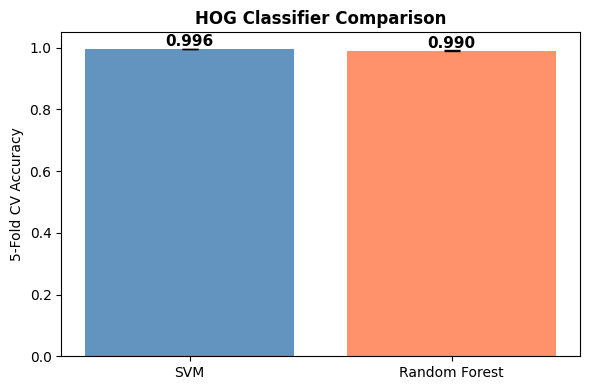

In [7]:
print('5-fold CV — SVM ...')
svm_cv = cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f'SVM  CV: {svm_cv.mean():.4f} ± {svm_cv.std():.4f}  {svm_cv.round(4)}')

print('5-fold CV — Random Forest ...')
rf_cv  = cross_val_score(rf_pipeline,  X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f'RF   CV: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}  {rf_cv.round(4)}')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['SVM', 'Random Forest'], [svm_cv.mean(), rf_cv.mean()],
              yerr=[svm_cv.std(), rf_cv.std()], capsize=6,
              color=['steelblue', 'coral'], alpha=0.85)
ax.set_ylim([0, 1.05]); ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('HOG Classifier Comparison', fontweight='bold')
for bar, m in zip(bars, [svm_cv.mean(), rf_cv.mean()]):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.01, f'{m:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 8️⃣ Generate Predictions 

In [8]:
BEST_MODEL = svm_pipeline
MODEL_NAME = 'SVM'

print(f'Generating predictions with {MODEL_NAME} ...')
test_preds = BEST_MODEL.predict(X_test)

submission_df = pd.DataFrame({'Id': original_test_ids, 'category': test_preds})
submission_df.to_csv('hog_submission.csv', index=False)
print('Saved as hog_submission.csv')
print(submission_df.head(10))

Generating predictions with SVM ...
Saved as hog_submission.csv
      Id  category
0  56604         6
1  29396         3
2  43803         6
3  12313         0
4  10341         8
5  40355         3
6  41117         4
7  71324         7
8   6854         1
9  12761         8


## 🔟 Visualise Sample Predictions

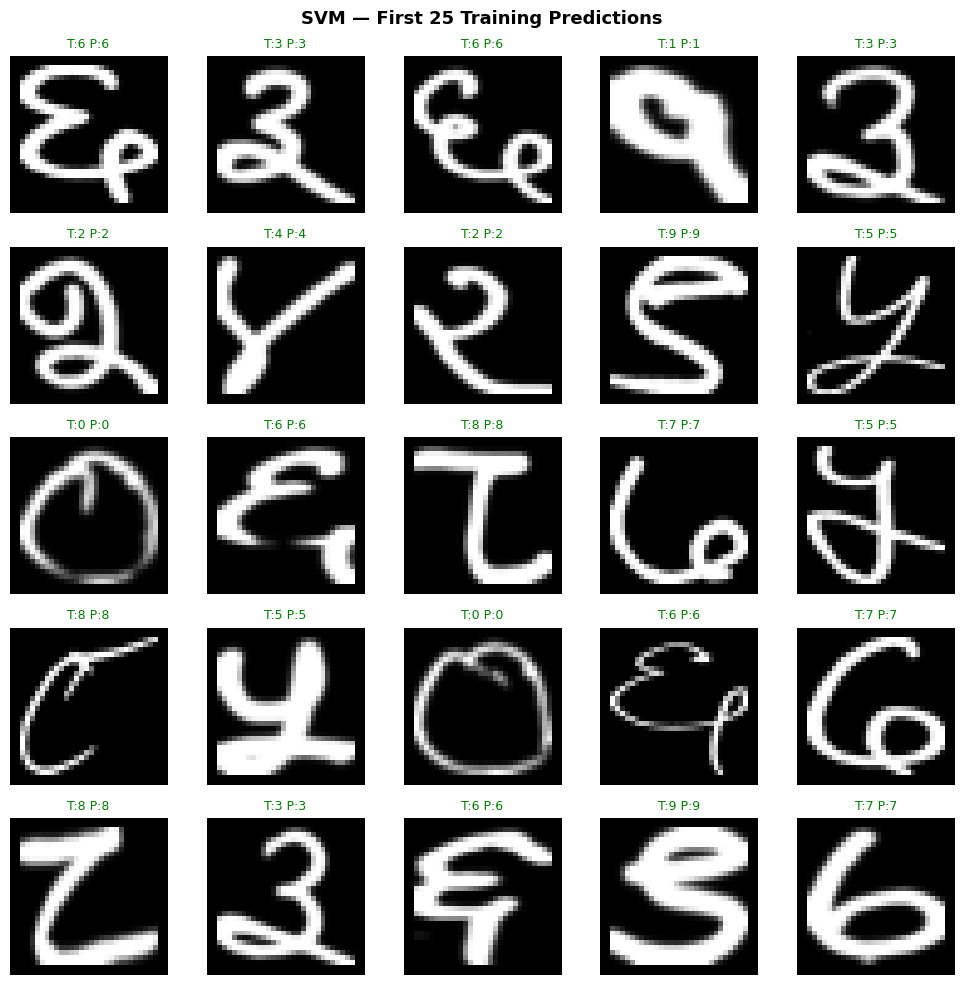

Green = correct | Red = wrong


In [9]:
sample_preds = svm_pipeline.predict(X_train[:25])
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle(f'{MODEL_NAME} — First 25 Training Predictions', fontsize=13, fontweight='bold')
axes = axes.flatten()
for i, ax in enumerate(axes):
    img = Image.open(os.path.join(training_images_dir, train_df['Id'].values[i])).convert('L')
    ax.imshow(np.array(img), cmap='gray')
    t, p = y_train[i], sample_preds[i]
    ax.set_title(f'T:{t} P:{p}', color='green' if t == p else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()
print('Green = correct | Red = wrong')